In [1]:
import os, glob, re
import pandas as pd
import numpy as np
from Bio import SeqIO
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)


plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica"]

def get_contig_stats(row):
    sample = str(row["sample"])
    contig_acc = str(row["Contig_acc"])
    fasta_file = f"{sample}_final_consensus.fasta"
    if not os.path.exists(fasta_file):
        return pd.Series({"sequence_length": np.nan, "N_count": np.nan, "N_percent": np.nan,"fasta_found": False,"contig_found": False})
    for record in SeqIO.parse(fasta_file, "fasta"):
        if record.id == contig_acc:
            seq = str(record.seq).upper()
            seq_len = len(seq)
            n_count = seq.count("N")
            n_percent = (n_count / seq_len * 100) if seq_len > 0 else np.nan
            return pd.Series({"sequence_length": seq_len,"N_count": n_count,"N_percent": n_percent,"fasta_found": True, "contig_found": True})
    return pd.Series({"sequence_length": np.nan,"N_count": np.nan,"N_percent": np.nan, "fasta_found": True,"contig_found": False})

MT=[]
for f in glob.glob("*EsViritu.detected_virus.info.tsv"):
    df=pd.read_csv(f, sep="\t")
    MT.append(df)

MT=pd.concat(MT)
MT=MT[MT["covered_bases"]>=1000]
MT = MT.drop(columns=['kingdom', 'phylum', 'tclass', 'order','Segment', 'Assembly'], errors='ignore')

virbot=[]
for f in glob.glob("*_final_consensus_pos_contig_score.csv"):
    df=pd.read_csv(f)
    df["sample"]=re.sub("_final_consensus_pos_contig_score.csv", "", f)
    virbot.append(df)
virbot=pd.concat(virbot)
virbot["level"]=[x.count(";") for x in virbot["Likely_taxa"]]

11


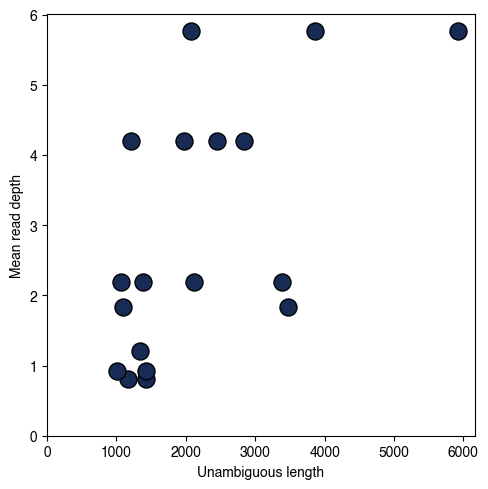

In [2]:
noro=virbot[(virbot["level"]>=6) & (virbot["Likely_taxa"].str.contains("Nor"))]
noro[["sequence_length", "N_count", "N_percent", "fasta_found", "contig_found"]] = (noro.apply(get_contig_stats, axis=1))
noro["unamb"] = noro["sequence_length"] - noro["N_count"]
passed_noro = noro[noro["unamb"] >= 1000].copy()
noro_mean_cov_dict = MT[MT["Name"].str.contains("Noro", na=False)].groupby("sample_ID")["mean_coverage"].mean().to_dict()
passed_noro["mean_coverage"]=passed_noro["sample"].map(noro_mean_cov_dict)

print(len(passed_noro["Contig_acc"].unique()))

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(passed_noro["unamb"],passed_noro["mean_coverage"],s=150,color="#182b55",edgecolor="black",linewidth=1, alpha=1)
ax.set_xlabel("Unambiguous length")
ax.set_ylabel("Mean read depth")

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()

plt.show()

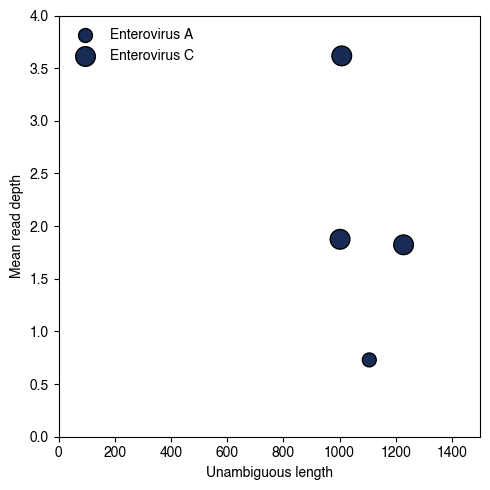

In [3]:
ent=virbot[(virbot["level"]>=7) & (virbot["Likely_taxa"].str.contains("Entero"))]
ent[["sequence_length", "N_count", "N_percent", "fasta_found", "contig_found"]] = (ent.apply(get_contig_stats, axis=1))
ent["unamb"] = ent["sequence_length"] - ent["N_count"]
passed_ent = ent[ent["unamb"] >= 1000].copy()


ent_mean_cov_dict = MT[MT["species"].str.contains("Entero", na=False)].groupby("sample_ID")["mean_coverage"].mean().to_dict()
passed_ent["mean_coverage"]=passed_ent["sample"].map(ent_mean_cov_dict)
ent_d=MT[MT["species"].str.contains("Entero", na=False)]
spec_d=dict(zip(ent_d["sample_ID"], ent_d["species"].str.replace("s__", "")))
passed_ent["species"]=passed_ent["sample"].map(spec_d)


size_dict = { "Enterovirus A": 100, "Enterovirus C": 200}
passed_ent = passed_ent.copy()
passed_ent["dot_size"] = passed_ent["species"].map(size_dict).fillna(150)

fig, ax = plt.subplots(figsize=(5, 5))

scatter = ax.scatter(passed_ent["unamb"], passed_ent["mean_coverage"],s=passed_ent["dot_size"],color="#182b55",edgecolor="black",linewidth=1,alpha=1)

ax.set_xlabel("Unambiguous length")
ax.set_ylabel("Mean read depth")
ax.set_xlim(0, 1500)
ax.set_ylim(0, 4)

handles = [ax.scatter( [], [], s=size, color="#182b55",edgecolor="black",linewidth=1,label=species  ) for species, size in size_dict.items()]

ax.legend(handles=handles, title="", frameon=False, bbox_to_anchor=(0.0, 1), loc="upper left")

plt.tight_layout()


plt.show()

In [4]:
sapo=virbot[(virbot["level"]>=7) & (virbot["Likely_taxa"].str.contains("Sap"))]
sapo[["sequence_length", "N_count", "N_percent", "fasta_found", "contig_found"]] = (sapo.apply(get_contig_stats, axis=1))
sapo["unamb"] = sapo["sequence_length"] - sapo["N_count"]
passed_sapo = sapo[sapo["unamb"] >= 1000].copy()

sapo

,Contig_acc,RNA-viral_gene_content,Encoded_proteins_num,Likely_taxa,sample,level,sequence_length,N_count,N_percent,fasta_found,contig_found,unamb
3,KX431437.1_consensus,1.0,1,Viruses; Riboviria; Orthornavirae; Pisuviricota; Pisoniviricetes; Picornavirales; Caliciviridae; Sapovirus; Sapporo virus.,EXP_DWS_3C,8,144,0,0.0,True,True,144
6,MN102395.1_consensus,1.0,1,Viruses; Riboviria; Orthornavirae; Pisuviricota; Pisoniviricetes; Picornavirales; Caliciviridae; Sapovirus; Sapporo virus.,MB_DWS_3C,8,228,0,0.0,True,True,228
0,MN102395.1_consensus,1.0,1,Viruses; Riboviria; Orthornavirae; Pisuviricota; Pisoniviricetes; Picornavirales; Caliciviridae; Sapovirus; Sapporo virus.,AJB_UPS_1A,8,250,0,0.0,True,True,250


In [5]:
# <!-- sapos identified under unclassified Calcis: MN102395.1_consensus',
#  'MN102397.1_consensus',
#  'AB623037.2_consensus',
#  'NC_010624.1_consensus',
#  'DQ366345.1_consensus',
#  'AY646856.2_consensus',
#  'LC504365.1_consensus']

blast_df=pd.read_csv("Calciviridaenospecies_passed_blast_top3.csv")
blast_df.drop_duplicates(subset="query_id", keep="first", inplace=True)
dd=dict(zip(blast_df["query_id"], blast_df["hit_def"]))
sapo=virbot[virbot["Contig_acc"].isin(['MN102395.1_consensus',
 'MN102397.1_consensus',
 'AB623037.2_consensus',
 'NC_010624.1_consensus',
 'DQ366345.1_consensus',
 'AY646856.2_consensus',
 'LC504365.1_consensus'])]
sapo[["sequence_length", "N_count", "N_percent", "fasta_found", "contig_found"]] = sapo.apply(get_contig_stats, axis=1)
sapo["unamb"] = sapo["sequence_length"] - sapo["N_count"]
passed_sapo = sapo[sapo["unamb"] >= 1000].copy()
sapo_mean_cov_dict = MT[MT["Name"].str.contains("Sapo", na=False)].groupby("sample_ID")["mean_coverage"].mean().to_dict()
passed_sapo["mean_coverage"]=passed_sapo["sample"].map(sapo_mean_cov_dict)
passed_sapo["Likely_taxa"]=passed_sapo["Contig_acc"].map(dd)

print(len(passed_sapo))


20


In [6]:
passed_sapo[0:3]

,Contig_acc,RNA-viral_gene_content,Encoded_proteins_num,Likely_taxa,sample,level,sequence_length,N_count,N_percent,fasta_found,contig_found,unamb,mean_coverage
8,MN102395.1_consensus,1.0,1,"Sapovirus sp. isolate SaV/A18/AFP18/NGR/2020/S018, complete genome",MB_MDS_3B,6,5567,3629,65.187713,True,True,1938,1.245937
22,MN102397.1_consensus,1.0,2,"Sapovirus GI isolate BRA/TO-66, complete genome",MB_MDS_3B,6,7015,3963,56.493229,True,True,3052,1.245937
6,AB623037.2_consensus,1.0,1,"Sapovirus GI.3 strain Hu/DE/2012/GI.3/Leipzig053 polyprotein gene, partial cds",EXP_UPS_1A,6,5595,4533,81.018767,True,True,1062,8.565570


In [7]:
df1=passed_noro[["unamb", "mean_coverage"]]
df1["species"]="Norovirus"
df2=passed_sapo[["unamb", "mean_coverage"]]
df2["species"]="Sapovirus"
df3=passed_ent[["unamb", "mean_coverage", "species"]]

In [8]:
len(df2)

20

In [9]:
df

,Contig_acc,RNA-viral_gene_content,Encoded_proteins_num,Likely_taxa,sample
0,KF039912.1_consensus,1.0,1,Viruses; Riboviria; Orthornavirae; Pisuviricota; Stelpaviricetes; Stellavirales; Astroviridae.,EXP_MDS_1B
1,NC_006269.1_consensus,1.0,1,Viruses; Riboviria; Orthornavirae; Pisuviricota; Pisoniviricetes; Picornavirales; Caliciviridae.,EXP_MDS_1B
2,OK500301.1_consensus,1.0,1,Viruses; Riboviria; Orthornavirae; Pisuviricota; Pisoniviricetes; Nidovirales; Coronaviridae; Betacoronavirus.,EXP_MDS_1B
3,MZ209753.1_consensus,1.0,1,Viruses; Riboviria.,EXP_MDS_1B
4,U80935.1_consensus,1.0,1,Viruses; Riboviria; Orthornavirae; Kitrinoviricota; Tolucaviricetes; Tolivirales; Tombusviridae; Tombusvirus.,EXP_MDS_1B
5,NC_001367.1_consensus,1.0,1,Viruses; Riboviria; Orthornavirae; Kitrinoviricota; Alsuviricetes; Martellivirales; Virgaviridae; Tobamovirus.,EXP_MDS_1B


In [10]:
alles=pd.concat([df1, df2, df3])

In [11]:
cols=['#182b55','#5f4e94', '#a291c7', '#900c3f','#82cbec','#d94f21','#febd2b','#9aab4b', "#8C92AC", "#9b2226", "#6a4c93", "#1982c4", "#8ac926", "#ff595e", "#FFFDD0", "#ffca3a",  "#8338ec", "#3a86ff"]


In [12]:
len(alles[alles["species"]=="Norovirus"])

18

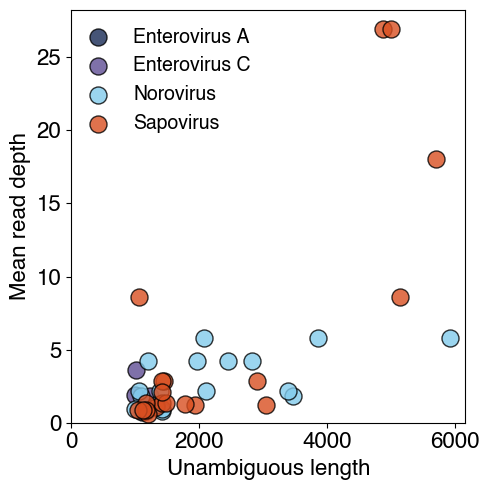

In [13]:
Colours = ["#182b55", "#5f4e94", "#82cbec", '#d94f21']
fig, ax = plt.subplots(figsize=(5, 5))
species_order = sorted(alles["species"].dropna().unique())
colour_dict = dict(zip(species_order, Colours))

for sp in species_order:
    sdf = alles[alles["species"] == sp]

    ax.scatter(sdf["unamb"],sdf["mean_coverage"],s=150,color=colour_dict[sp],edgecolor="black",linewidth=1,alpha=0.8,label=sp)

ax.set_xlabel("Unambiguous length", fontsize=16)
ax.set_ylabel("Mean read depth", fontsize=16)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.tick_params(axis="both", labelsize=16)

ax.legend(title="",frameon=False,bbox_to_anchor=(0.5, 1), fontsize=14)
plt.tight_layout()


plt.show()

In [14]:
# <!-- atros identified under astroviridae',
# [ 'MK059955.1_consensus',  'KF039912.1_consensus', 'NC_011400.1_consensus',
#   'MZ546174.1_consensus',  'MW485042.1_consensus', 'NC_030922.1_consensus',
#   'KP862744.1_consensus',  'LC694990.1_consensus',  'HM237363.1_consensus',
#   'GQ495608.1_consensus',  'DQ344027.1_consensus',  'MW485043.1_consensus',
#   'KF039911.1_consensus', 'NC_013443.1_consensus']

blast_df=pd.read_csv("Astroviridae_species_passed_blast_top3.csv")
blast_df.drop_duplicates(subset="query_id", keep="first", inplace=True)
dd=dict(zip(blast_df["query_id"], blast_df["hit_def"]))
astro=virbot[virbot["Contig_acc"].isin([ 'MK059955.1_consensus',  'KF039912.1_consensus', 'NC_011400.1_consensus',
  'MZ546174.1_consensus',  'MW485042.1_consensus', 'NC_030922.1_consensus',
  'KP862744.1_consensus',  'LC694990.1_consensus',  'HM237363.1_consensus',
  'GQ495608.1_consensus',  'DQ344027.1_consensus',  'MW485043.1_consensus',
  'KF039911.1_consensus', 'NC_013443.1_consensus'])]
astro[["sequence_length", "N_count", "N_percent", "fasta_found", "contig_found"]] = astro.apply(get_contig_stats, axis=1)
astro["unamb"] = astro["sequence_length"] - astro["N_count"]
passed_astro = astro[astro["unamb"] >= 1000].copy()
astro_mean_cov_dict = MT[MT["Name"].str.contains("Sapo", na=False)].groupby("sample_ID")["mean_coverage"].mean().to_dict()
passed_astro["mean_coverage"]=passed_astro["sample"].map(sapo_mean_cov_dict)
passed_astro["Likely_taxa"]=passed_astro["Contig_acc"].map(dd)
print(len(passed_astro))


68


In [15]:
blast_df=pd.read_csv("Picornaviridae_species_passed_blast_top3.csv")
blast_df.drop_duplicates(subset="query_id", keep="first", inplace=True)
dd=dict(zip(blast_df["query_id"], blast_df["hit_def"]))
hits=blast_df[blast_df["hit_def"].str.contains("Salivi")]["query_id"].to_list()
sali=virbot[virbot["Contig_acc"].isin(hits)]
sali[["sequence_length", "N_count", "N_percent", "fasta_found", "contig_found"]] = sali.apply(get_contig_stats, axis=1)
sali["unamb"] = sali["sequence_length"] - sali["N_count"]
passed_sali = sali[sali["unamb"] >= 1000].copy()
sali_mean_cov_dict = MT[MT["Name"].str.contains("Sapo", na=False)].groupby("sample_ID")["mean_coverage"].mean().to_dict()
passed_sali["mean_coverage"]=passed_sali["sample"].map(sapo_mean_cov_dict)
passed_sali["Likely_taxa"]=passed_sali["Contig_acc"].map(dd)
print(len(passed_sali))



12


In [16]:
df4=passed_astro[["unamb", "mean_coverage"]]
df4["species"]="Astrovirus"

df5=passed_sali[["unamb", "mean_coverage"]]
df5["species"]="Salivirus"

In [17]:
alles=pd.concat([df1, df2, df3, df4])

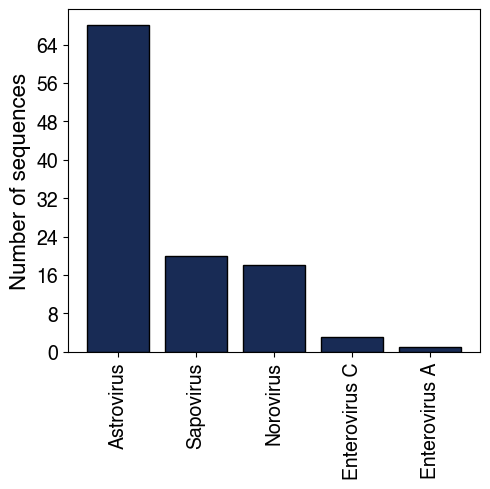

In [22]:

s_c = alles.groupby("species").size().reset_index(name="count").sort_values("count", ascending=False)

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(s_c["species"],s_c["count"],color="#182b55", edgecolor="black",linewidth=1)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("")
ax.set_ylabel("Number of sequences", fontsize=16)
ax.tick_params(axis="x")
ax.tick_params(axis="both", colors="black", labelsize=14)

ax.tick_params(axis="x", labelrotation=90)

for spine in ax.spines.values():
    spine.set_color("black")

plt.tight_layout()

plt.show()